# Setup

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

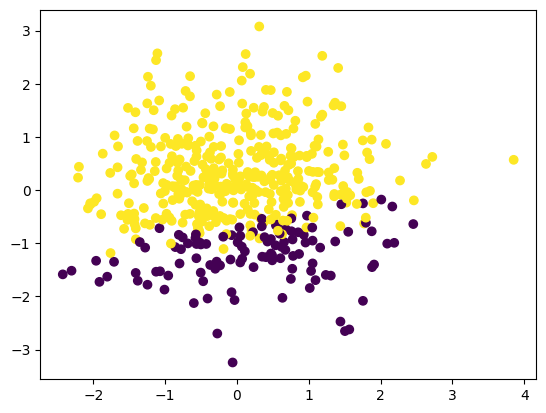

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

# Dataset: logistic_data_A

In [4]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


## Learning Rate: lr = 0.1

50. Training loss: 0.42788681156341524, Val loss:0.4289337233194825
100. Training loss: 0.3186543688258759, Val loss:0.330744022589277
150. Training loss: 0.2756136848389012, Val loss:0.2918366320362445
200. Training loss: 0.2515647449518196, Val loss:0.27001137334938924
250. Training loss: 0.23586370599134487, Val loss:0.2557354638551537
300. Training loss: 0.2246778376496635, Val loss:0.24556151612210977
350. Training loss: 0.21624915555159713, Val loss:0.2379013150251245
400. Training loss: 0.20964409595419933, Val loss:0.23190816484103668
450. Training loss: 0.20431563313153664, Val loss:0.2270843249497499
500. Training loss: 0.19991967899618934, Val loss:0.22311586759002253


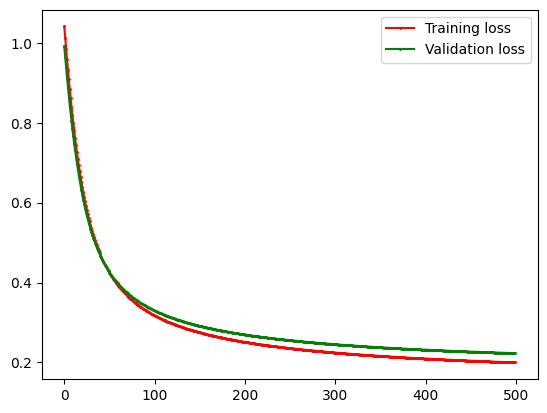

In [5]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.1,n_iteration=500,val_ratio=0.2)

In [6]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


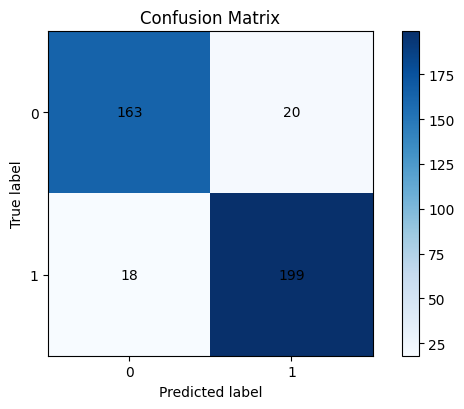

{'Accuracy': 0.905,
 'Precision': 0.908675799086758,
 'Recall': 0.9170506912442397,
 'F1-score': 0.9128440366972477}

In [7]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

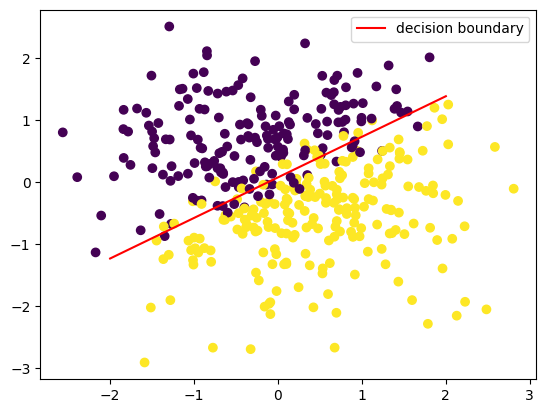

In [8]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.01

### Iterations: n_iteration = 500

50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.7007176536422792
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.5025287985878911, Val loss:0.5015278107602669
400. Training loss: 0.472286903656601, Val loss:0.47335285416404
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430745, Val loss:0.43054684173876917


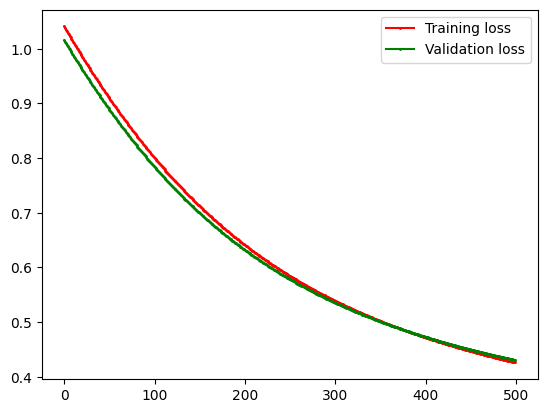

In [9]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=500,val_ratio=0.2)

In [10]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


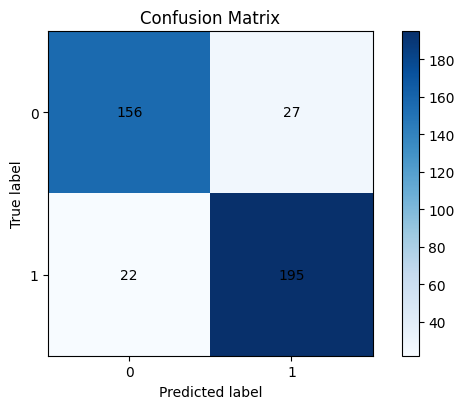

{'Accuracy': 0.8775,
 'Precision': 0.8783783783783784,
 'Recall': 0.8986175115207373,
 'F1-score': 0.8883826879271071}

In [11]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

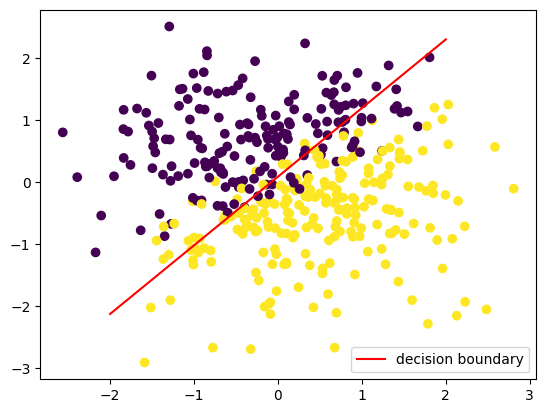

In [12]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1000

50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.7007176536422792
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.5025287985878911, Val loss:0.5015278107602669
400. Training loss: 0.472286903656601, Val loss:0.47335285416404
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430745, Val loss:0.43054684173876917
550. Training loss: 0.4081728908570478, Val loss:0.4139746471541715
600. Training loss: 0.39272216283590505, Val loss:0.39973270897578933
650. Training loss: 0.3792774530955586, Val loss:0.38735889620900993
700. Training loss: 0.3674662456334753, Val loss:0.3765019336049603
750. Training loss: 0.35700075616242133, Val lo

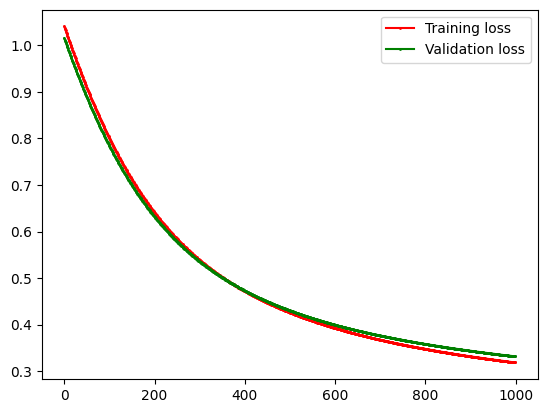

In [13]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1000,val_ratio=0.2)

In [14]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9025
Precision : 0.9045
Recall    : 0.9171
F1-score  : 0.9108


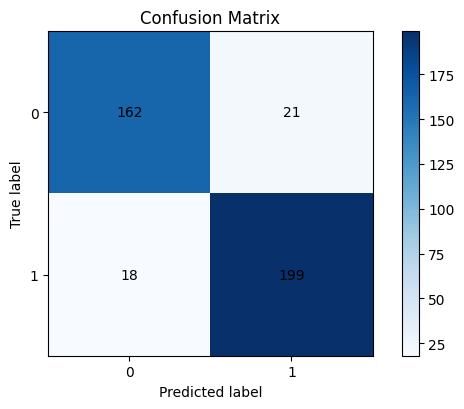

{'Accuracy': 0.9025,
 'Precision': 0.9045454545454545,
 'Recall': 0.9170506912442397,
 'F1-score': 0.9107551487414187}

In [15]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

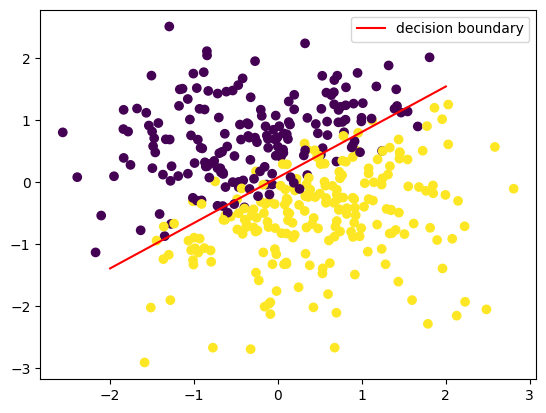

In [16]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1500

50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.7007176536422792
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.5025287985878911, Val loss:0.5015278107602669
400. Training loss: 0.472286903656601, Val loss:0.47335285416404
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430745, Val loss:0.43054684173876917
550. Training loss: 0.4081728908570478, Val loss:0.4139746471541715
600. Training loss: 0.39272216283590505, Val loss:0.39973270897578933
650. Training loss: 0.3792774530955586, Val loss:0.38735889620900993
700. Training loss: 0.3674662456334753, Val loss:0.3765019336049603
750. Training loss: 0.35700075616242133, Val lo

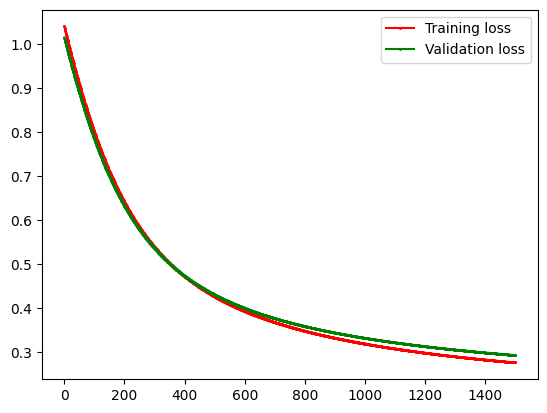

In [17]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1500,val_ratio=0.2)

In [18]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9025
Precision : 0.9083
Recall    : 0.9124
F1-score  : 0.9103


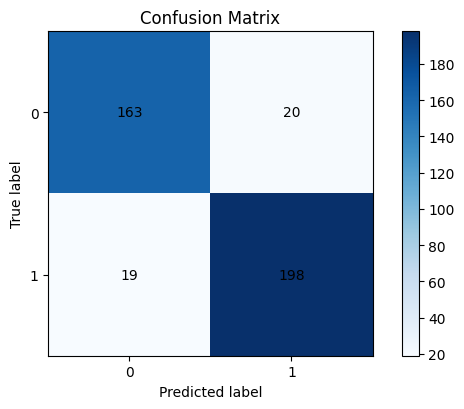

{'Accuracy': 0.9025,
 'Precision': 0.908256880733945,
 'Recall': 0.9124423963133641,
 'F1-score': 0.9103448275862069}

In [19]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

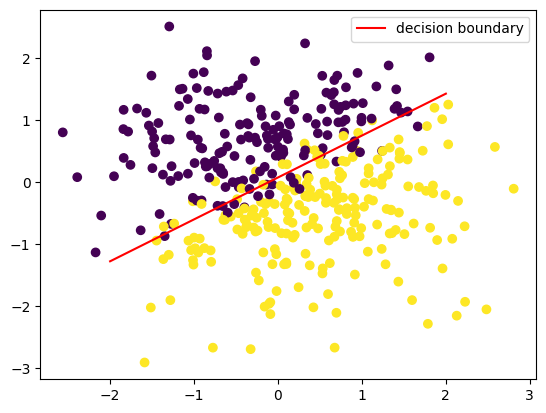

In [20]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.001

50. Training loss: 1.0269460601586051, Val loss:1.0044831492028101
100. Training loss: 1.0129964397614701, Val loss:0.9909719737552948
150. Training loss: 0.9992783487558338, Val loss:0.9776880822134313
200. Training loss: 0.9857916009817304, Val loss:0.9646313599916955
250. Training loss: 0.9725358539101562, Val loss:0.9518015338881938
300. Training loss: 0.9595106080951761, Val loss:0.9391981713655223
350. Training loss: 0.9467152071471594, Val loss:0.9268206803770204
400. Training loss: 0.9341488382362755, Val loss:0.9146683097467531
450. Training loss: 0.921810533131396, Val loss:0.902740150107322
500. Training loss: 0.9096991697753719, Val loss:0.8910351353952262


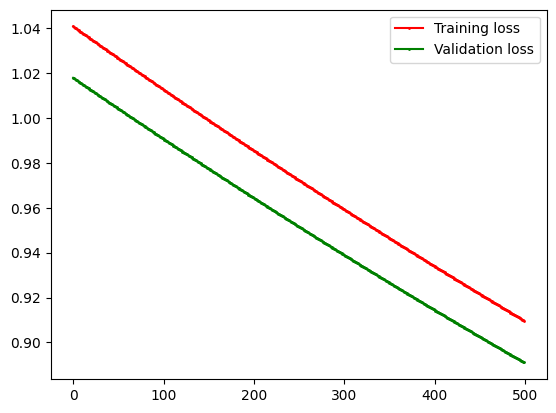

In [21]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.001,n_iteration=500,val_ratio=0.2)

In [22]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.3875
Precision : 0.4364
Recall    : 0.4424
F1-score  : 0.4394


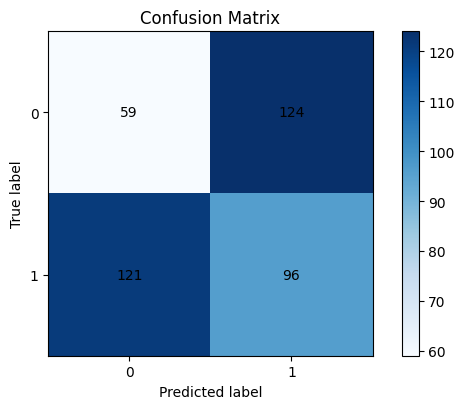

{'Accuracy': 0.3875,
 'Precision': 0.43636363636363634,
 'Recall': 0.4423963133640553,
 'F1-score': 0.43935926773455375}

In [23]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

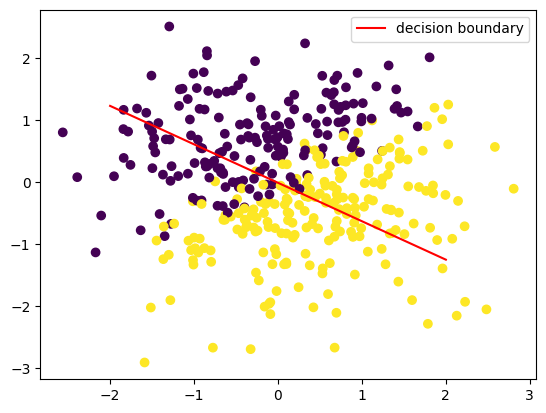

In [24]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

# Dataset: logistic_data_B

In [25]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_B.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


## Learning Rate: lr = 0.1

50. Training loss: 0.5103175622043802, Val loss:0.5083432819772871
100. Training loss: 0.4370955155097443, Val loss:0.4380558711885709
150. Training loss: 0.41557622016883045, Val loss:0.41686490530445874
200. Training loss: 0.4064609166991815, Val loss:0.40772460423377516
250. Training loss: 0.40189820214342353, Val loss:0.403075856575893
300. Training loss: 0.39939491697142937, Val loss:0.4004811213417746
350. Training loss: 0.39794090751624056, Val loss:0.39894289148678264
400. Training loss: 0.3970632739456962, Val loss:0.3979910069463985
450. Training loss: 0.39651887299277666, Val loss:0.3973823809390223
500. Training loss: 0.39617431232724015, Val loss:0.39698286902644125


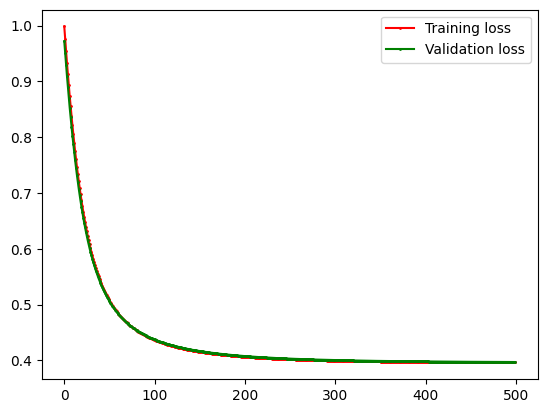

In [26]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.1,n_iteration=500,val_ratio=0.2)

In [27]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.7800
Precision : 0.7793
Recall    : 0.8160
F1-score  : 0.7972


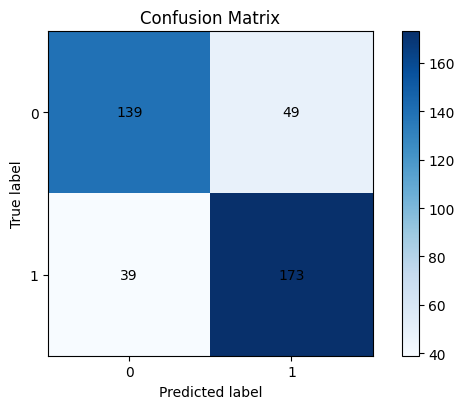

{'Accuracy': 0.78,
 'Precision': 0.7792792792792793,
 'Recall': 0.8160377358490566,
 'F1-score': 0.7972350230414746}

In [28]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

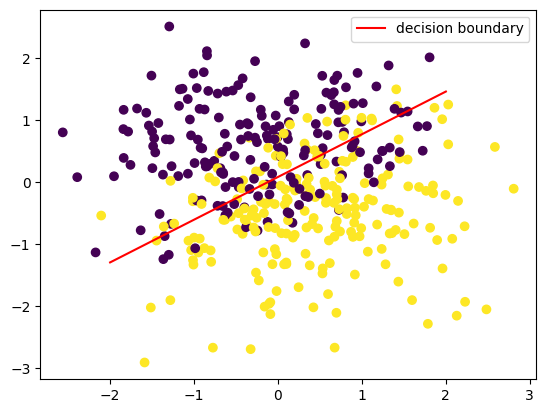

In [29]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.01

### Iterations: n_iteration = 500

50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.8083096467352318, Val loss:0.804210107205688
150. Training loss: 0.7369603264945954, Val loss:0.7337661725077593
200. Training loss: 0.6795500174801886, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195072, Val loss:0.6320453148336889
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962918, Val loss:0.567319509722204
400. Training loss: 0.5441528833412147, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803


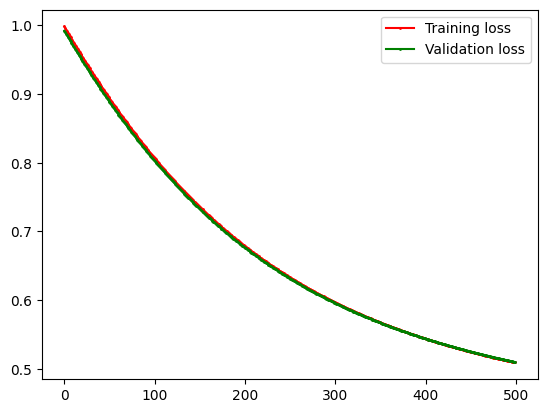

In [30]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=500,val_ratio=0.2)

In [31]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.7625
Precision : 0.7600
Recall    : 0.8066
F1-score  : 0.7826


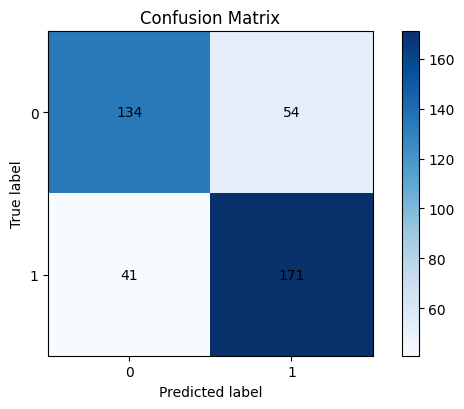

{'Accuracy': 0.7625,
 'Precision': 0.76,
 'Recall': 0.8066037735849056,
 'F1-score': 0.782608695652174}

In [32]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

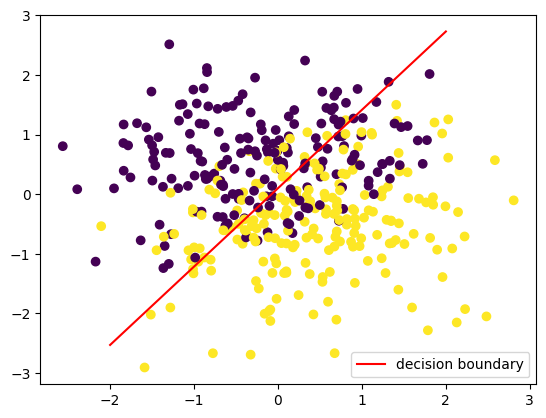

In [33]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1000

50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.8083096467352318, Val loss:0.804210107205688
150. Training loss: 0.7369603264945954, Val loss:0.7337661725077593
200. Training loss: 0.6795500174801886, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195072, Val loss:0.6320453148336889
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962918, Val loss:0.567319509722204
400. Training loss: 0.5441528833412147, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803
550. Training loss: 0.4958754025373824, Val loss:0.4967249285603096
600. Training loss: 0.48481807604794447, Val loss:0.4858517431539401
650. Training loss: 0.47544801408599946, Val loss:0.4766264014194725
700. Training loss: 0.46743824703384007, Val loss:0.4687295376448458
750. Training loss: 0.4605361029338294, Val loss

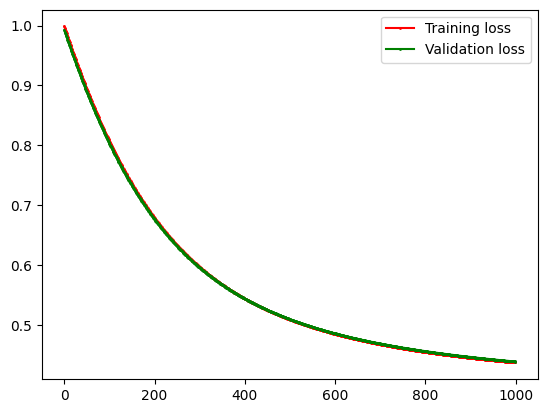

In [34]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1000,val_ratio=0.2)

In [35]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


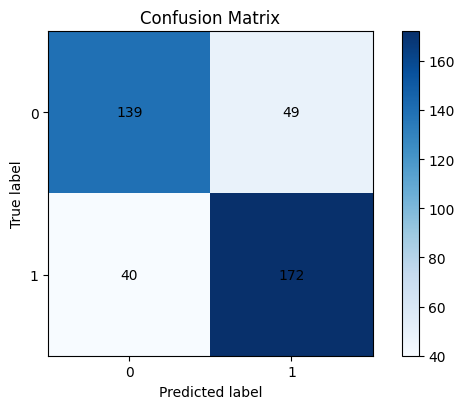

{'Accuracy': 0.7775,
 'Precision': 0.7782805429864253,
 'Recall': 0.8113207547169812,
 'F1-score': 0.7944572748267898}

In [36]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

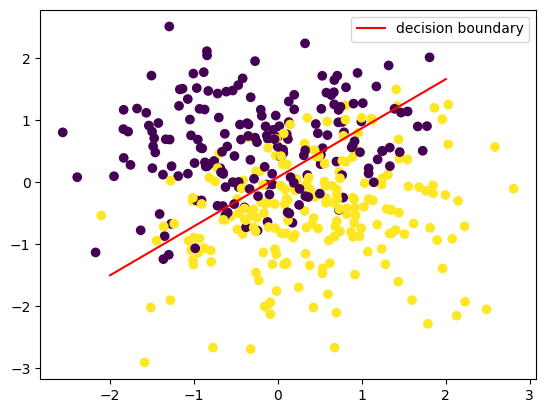

In [37]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1500

50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.8083096467352318, Val loss:0.804210107205688
150. Training loss: 0.7369603264945954, Val loss:0.7337661725077593
200. Training loss: 0.6795500174801886, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195072, Val loss:0.6320453148336889
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962918, Val loss:0.567319509722204
400. Training loss: 0.5441528833412147, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803
550. Training loss: 0.4958754025373824, Val loss:0.4967249285603096
600. Training loss: 0.48481807604794447, Val loss:0.4858517431539401
650. Training loss: 0.47544801408599946, Val loss:0.4766264014194725
700. Training loss: 0.46743824703384007, Val loss:0.4687295376448458
750. Training loss: 0.4605361029338294, Val loss

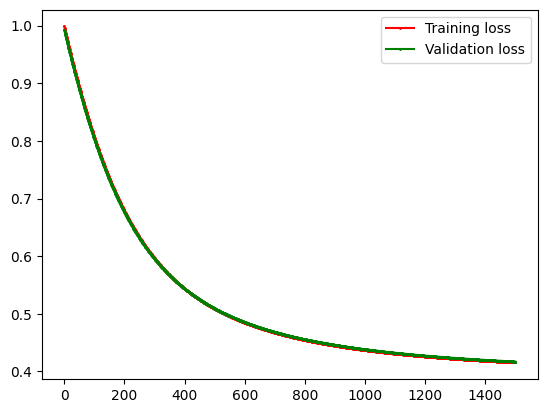

In [38]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1500,val_ratio=0.2)

In [39]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


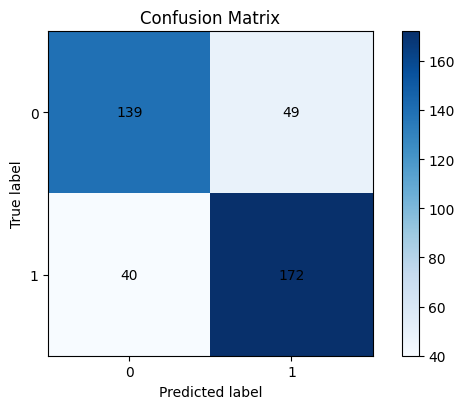

{'Accuracy': 0.7775,
 'Precision': 0.7782805429864253,
 'Recall': 0.8113207547169812,
 'F1-score': 0.7944572748267898}

In [40]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

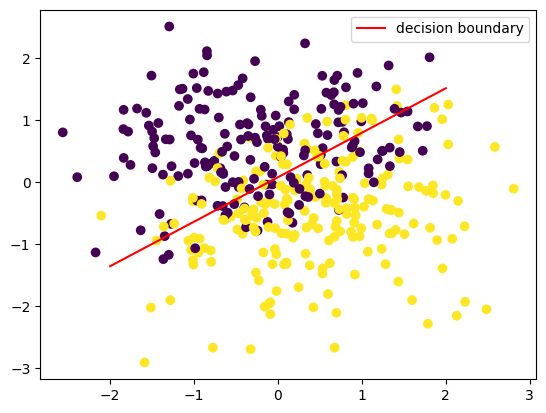

In [41]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.001

50. Training loss: 0.9874379008463233, Val loss:0.9833381665312408
100. Training loss: 0.9763421106130916, Val loss:0.9723285004243568
150. Training loss: 0.9654284713499054, Val loss:0.9614993121069902
200. Training loss: 0.9546966109038486, Val loss:0.9508503118676398
250. Training loss: 0.9441460548822513, Val loss:0.9403811053688884
300. Training loss: 0.9337762268335361, Val loss:0.9300911936941736
350. Training loss: 0.9235864487116803, Val loss:0.9199799736931847
400. Training loss: 0.9135759416259137, Val loss:0.9100467386272083
450. Training loss: 0.9037438268754272, Val loss:0.900290679113813
500. Training loss: 0.8940891272670412, Val loss:0.8907108843683351


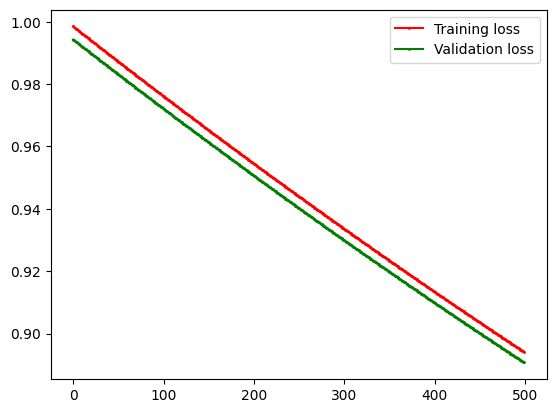

In [42]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.001,n_iteration=500,val_ratio=0.2)

In [43]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.3925
Precision : 0.4286
Recall    : 0.4387
F1-score  : 0.4336


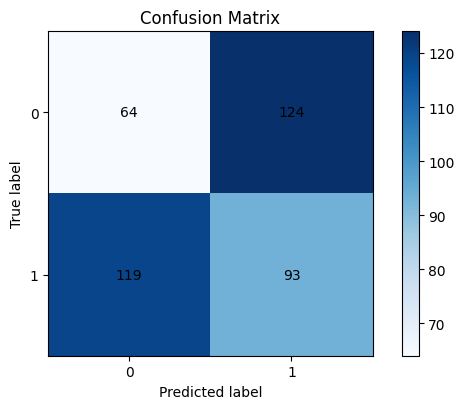

{'Accuracy': 0.3925,
 'Precision': 0.42857142857142855,
 'Recall': 0.4386792452830189,
 'F1-score': 0.43356643356643354}

In [44]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

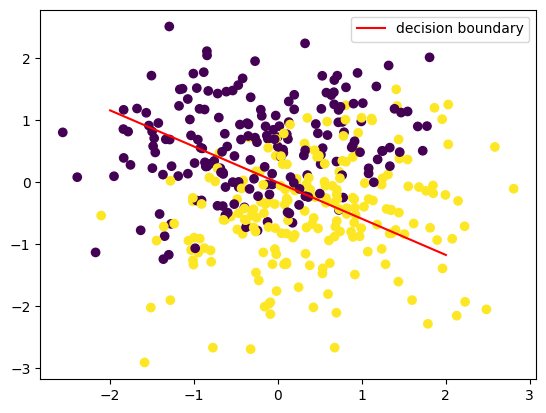

In [45]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

# Dataset: logistic_data_C

In [46]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_C.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


## Learning Rate: lr = 0.1

50. Training loss: 0.2914041500436065, Val loss:0.3046140440301792
100. Training loss: 0.24213528492723757, Val loss:0.2580888835834869
150. Training loss: 0.21536654598435145, Val loss:0.2322484565856379
200. Training loss: 0.19747326685613664, Val loss:0.21464876637946467
250. Training loss: 0.18425966445090686, Val loss:0.20146358893625357
300. Training loss: 0.17392662515639434, Val loss:0.1910406239651334
350. Training loss: 0.16553563334078472, Val loss:0.18250642396014669
400. Training loss: 0.1585343471516416, Val loss:0.17533939085232825
450. Training loss: 0.15257074008482724, Val loss:0.1692025922688029
500. Training loss: 0.14740737629117945, Val loss:0.16386616021059386


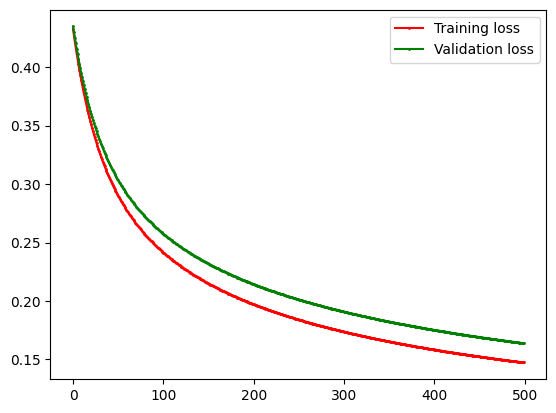

In [47]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.1,n_iteration=500,val_ratio=0.2)

In [48]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9762
Precision : 0.9852
Recall    : 0.9719
F1-score  : 0.9785


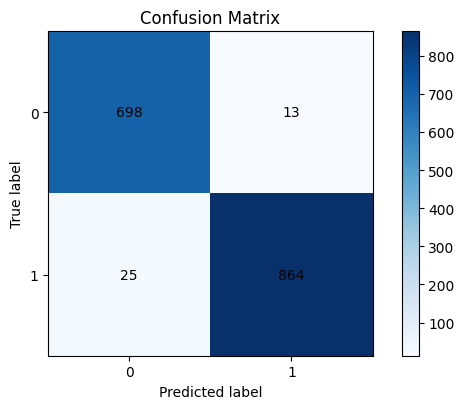

{'Accuracy': 0.97625,
 'Precision': 0.9851767388825542,
 'Recall': 0.9718785151856018,
 'F1-score': 0.9784824462061155}

In [49]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

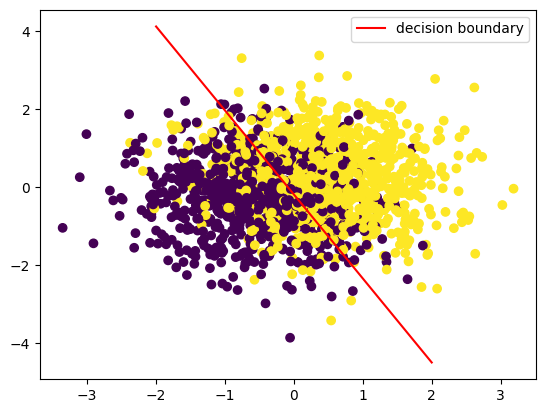

In [50]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.01

### Iterations: n_iteration = 500

50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.3782638648505192
200. Training loss: 0.35195423947335824, Val loss:0.3633283168299958
250. Training loss: 0.3382753435702528, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.32902400827673756
400. Training loss: 0.30642350649863626, Val loss:0.3201340925514731
450. Training loss: 0.298054739548878, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056


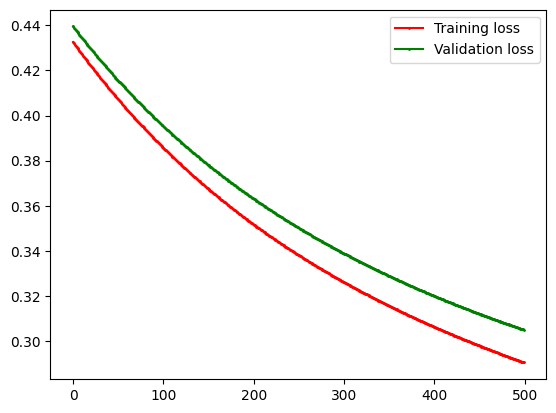

In [51]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=500,val_ratio=0.2)

In [52]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9456
Precision : 0.9707
Recall    : 0.9303
F1-score  : 0.9500


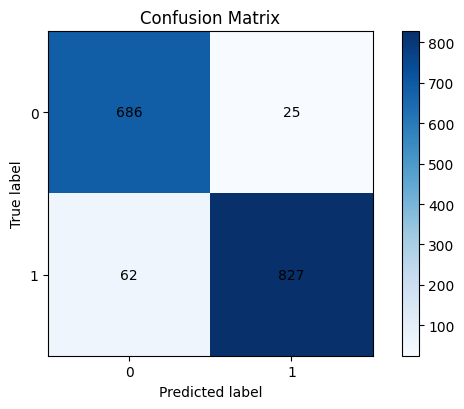

{'Accuracy': 0.945625,
 'Precision': 0.9706572769953051,
 'Recall': 0.9302587176602924,
 'F1-score': 0.9500287191269385}

In [53]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

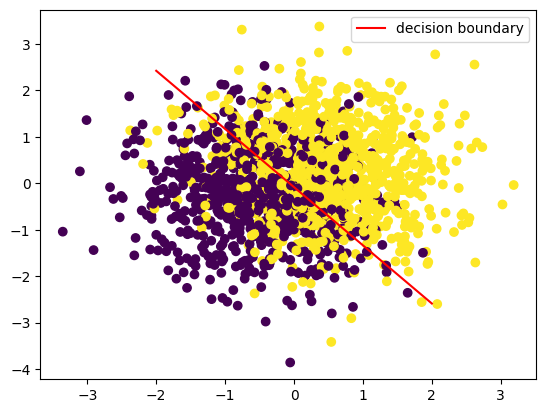

In [54]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1000

50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.3782638648505192
200. Training loss: 0.35195423947335824, Val loss:0.3633283168299958
250. Training loss: 0.3382753435702528, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.32902400827673756
400. Training loss: 0.30642350649863626, Val loss:0.3201340925514731
450. Training loss: 0.298054739548878, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056
550. Training loss: 0.28369081715291194, Val loss:0.29849682447858894
600. Training loss: 0.27746738153908257, Val loss:0.2925604725198355
650. Training loss: 0.27176454986406984, Val loss:0.2871142640230998
700. Training loss: 0.26651273728471975, Val loss:0.28209239966841937
750. Training loss: 0.26165409726610

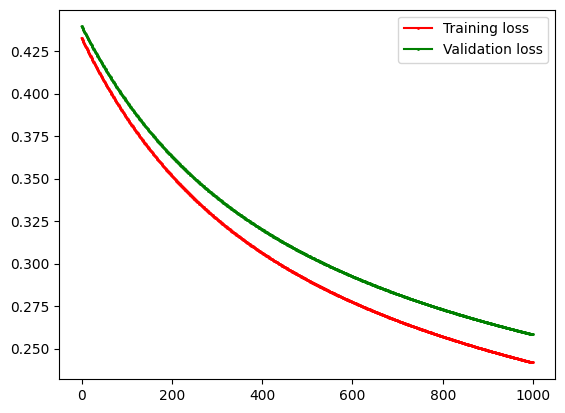

In [55]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1000,val_ratio=0.2)

In [56]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9744
Precision : 0.9885
Recall    : 0.9651
F1-score  : 0.9767


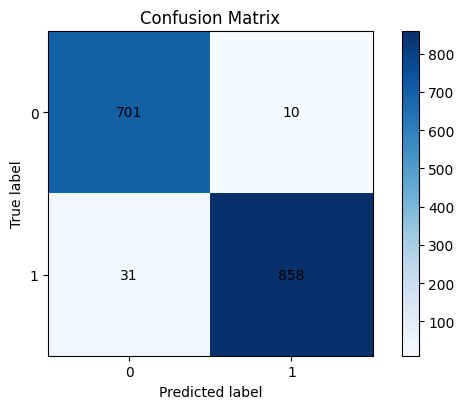

{'Accuracy': 0.974375,
 'Precision': 0.988479262672811,
 'Recall': 0.9651293588301463,
 'F1-score': 0.9766647694934547}

In [57]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

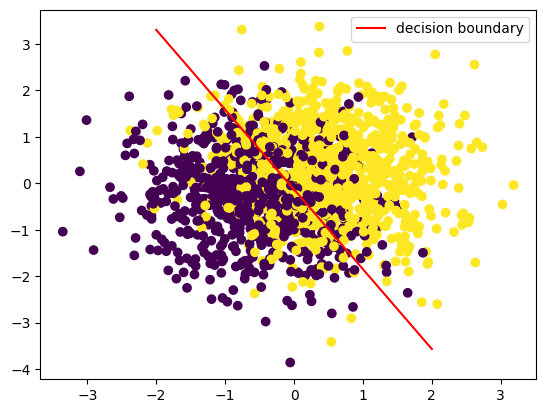

In [58]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1500

50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.3782638648505192
200. Training loss: 0.35195423947335824, Val loss:0.3633283168299958
250. Training loss: 0.3382753435702528, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.32902400827673756
400. Training loss: 0.30642350649863626, Val loss:0.3201340925514731
450. Training loss: 0.298054739548878, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056
550. Training loss: 0.28369081715291194, Val loss:0.29849682447858894
600. Training loss: 0.27746738153908257, Val loss:0.2925604725198355
650. Training loss: 0.27176454986406984, Val loss:0.2871142640230998
700. Training loss: 0.26651273728471975, Val loss:0.28209239966841937
750. Training loss: 0.26165409726610

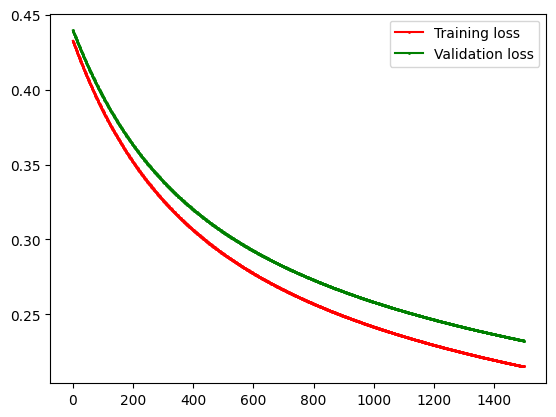

In [59]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1500,val_ratio=0.2)

In [60]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9788
Precision : 0.9897
Recall    : 0.9719
F1-score  : 0.9807


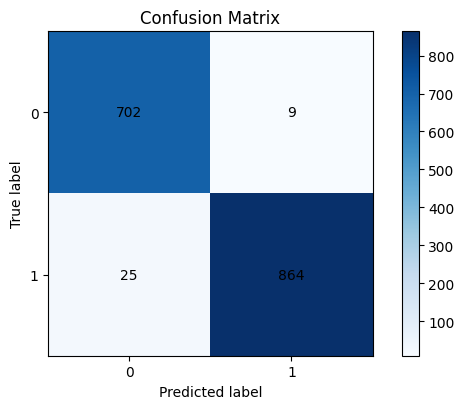

{'Accuracy': 0.97875,
 'Precision': 0.9896907216494846,
 'Recall': 0.9718785151856018,
 'F1-score': 0.9807037457434733}

In [61]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

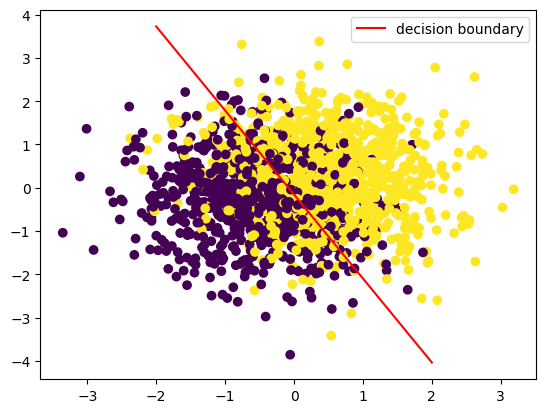

In [62]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.001

50. Training loss: 0.4298821030676496, Val loss:0.43740830867066577
100. Training loss: 0.4271883654785384, Val loss:0.43486105109553536
150. Training loss: 0.42454112656343235, Val loss:0.4323574765831896
200. Training loss: 0.42193938784995444, Val loss:0.42989664927305665
250. Training loss: 0.4193821724637837, Val loss:0.4274776538321253
300. Training loss: 0.41686852479007863, Val loss:0.4250995951031024
350. Training loss: 0.41439751012942966, Val loss:0.42276159774950733
400. Training loss: 0.4119682143493205, Val loss:0.4204628058985884
450. Training loss: 0.40957974353201126, Val loss:0.4182023827828775
500. Training loss: 0.40723122361969855, Val loss:0.4159795103811309


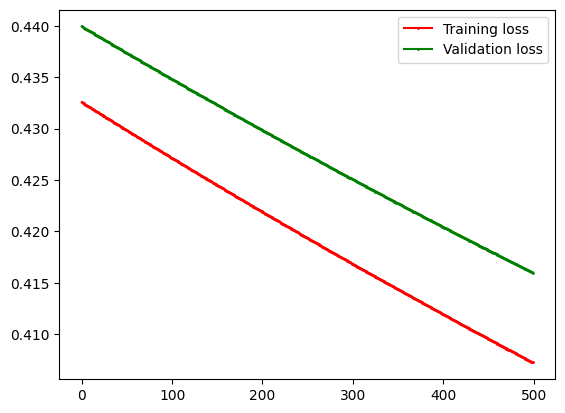

In [63]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.001,n_iteration=500,val_ratio=0.2)

In [64]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.8406
Precision : 0.8774
Recall    : 0.8290
F1-score  : 0.8525


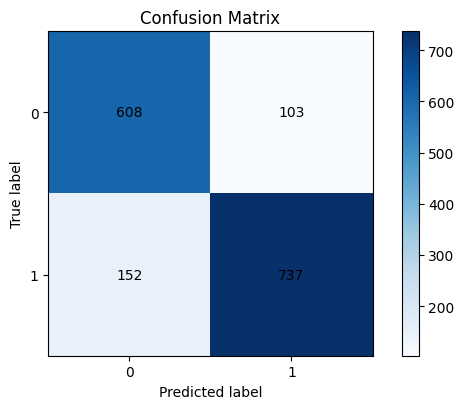

{'Accuracy': 0.840625,
 'Precision': 0.8773809523809524,
 'Recall': 0.829021372328459,
 'F1-score': 0.8525159051474841}

In [65]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

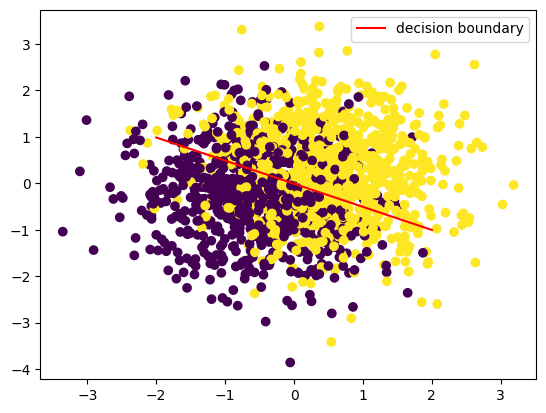

In [66]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

# Dataset: logistic_data_D

In [67]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


## Learning Rate: lr = 0.1

50. Training loss: 0.31214565926023174, Val loss:0.32389957055379487
100. Training loss: 0.2680253579500514, Val loss:0.28459011684914537
150. Training loss: 0.24507991801016668, Val loss:0.26367143739005755
200. Training loss: 0.23025970529698733, Val loss:0.24981367489682632
250. Training loss: 0.21963615020155505, Val loss:0.23967468756947913
300. Training loss: 0.2115547767275018, Val loss:0.2318441744405014
350. Training loss: 0.20516346620008113, Val loss:0.22558274853425692
400. Training loss: 0.1999656677345639, Val loss:0.22044961112666256
450. Training loss: 0.19564762834057503, Val loss:0.21616005232291835
500. Training loss: 0.19199945372601435, Val loss:0.21251993712270312


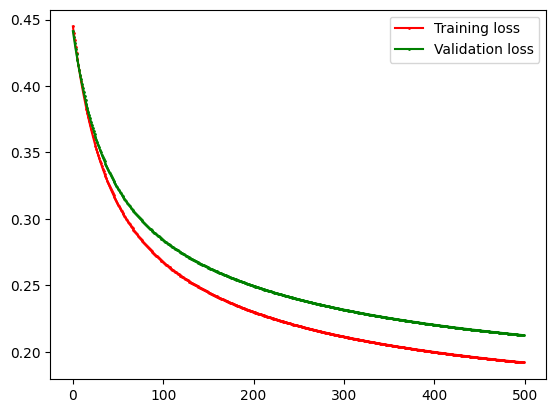

In [68]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.1,n_iteration=500,val_ratio=0.2)

In [69]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


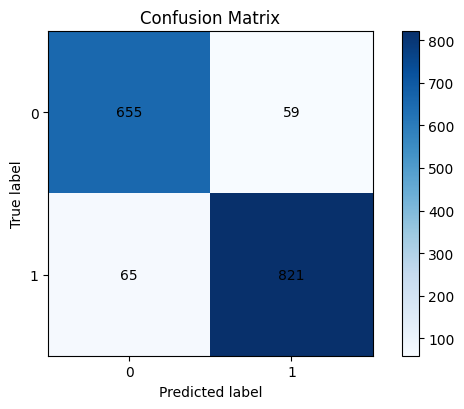

{'Accuracy': 0.9225,
 'Precision': 0.9329545454545455,
 'Recall': 0.9266365688487584,
 'F1-score': 0.9297848244620611}

In [70]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

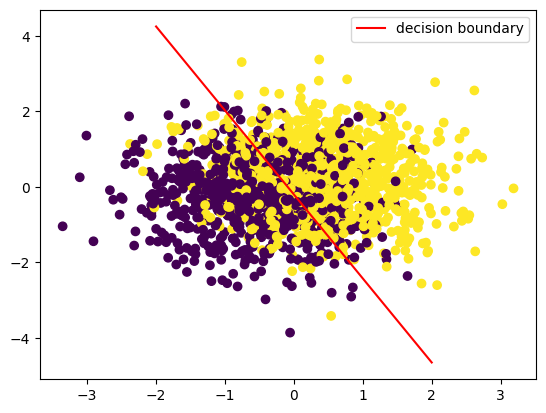

In [71]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.01

### Iterations: n_iteration = 500

50. Training loss: 0.4210863364107006, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061348, Val loss:0.4052693942293411
150. Training loss: 0.3833104146387553, Val loss:0.38946444714134726
200. Training loss: 0.36844391326627834, Val loss:0.3759451207657198
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.34443109894084123, Val loss:0.35415496178424605
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.33744318725215144
450. Training loss: 0.31825604822090914, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966


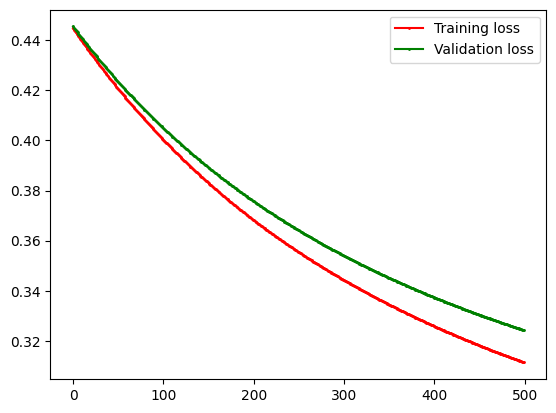

In [72]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=500,val_ratio=0.2)

In [73]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9113
Precision : 0.9346
Recall    : 0.9029
F1-score  : 0.9185


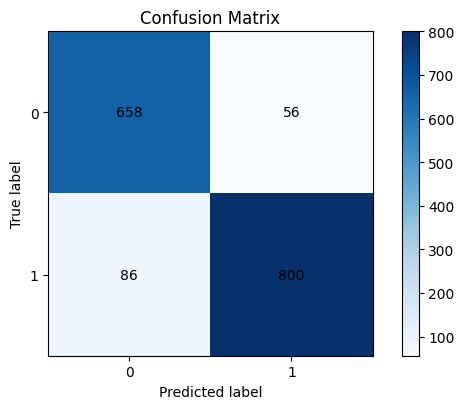

{'Accuracy': 0.91125,
 'Precision': 0.9345794392523364,
 'Recall': 0.9029345372460497,
 'F1-score': 0.9184845005740528}

In [74]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

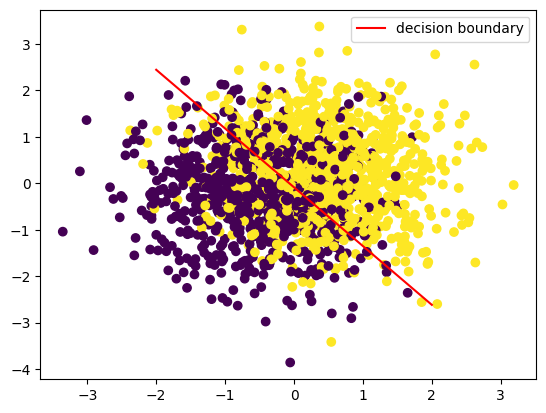

In [75]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1000

50. Training loss: 0.4210863364107006, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061348, Val loss:0.4052693942293411
150. Training loss: 0.3833104146387553, Val loss:0.38946444714134726
200. Training loss: 0.36844391326627834, Val loss:0.3759451207657198
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.34443109894084123, Val loss:0.35415496178424605
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.33744318725215144
450. Training loss: 0.31825604822090914, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966
550. Training loss: 0.30512120261559816, Val loss:0.31861866833458574
600. Training loss: 0.29947398138187187, Val loss:0.31352230201213016
650. Training loss: 0.29432499674933427, Val loss:0.3088748500410424
700. Training loss: 0.28960656875428886, Val loss:0.3046141303741866
750. Training loss: 0.28526247

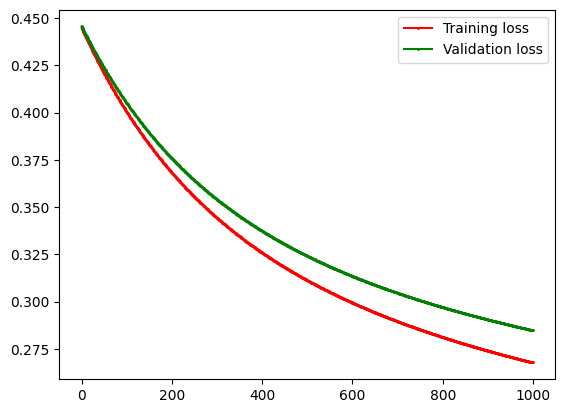

In [76]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1000,val_ratio=0.2)

In [77]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9263
Precision : 0.9394
Recall    : 0.9266
F1-score  : 0.9330


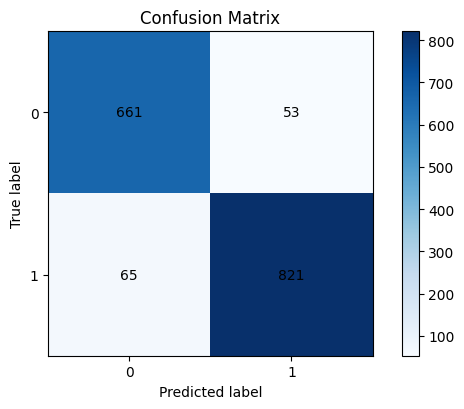

{'Accuracy': 0.92625,
 'Precision': 0.9393592677345538,
 'Recall': 0.9266365688487584,
 'F1-score': 0.9329545454545455}

In [78]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

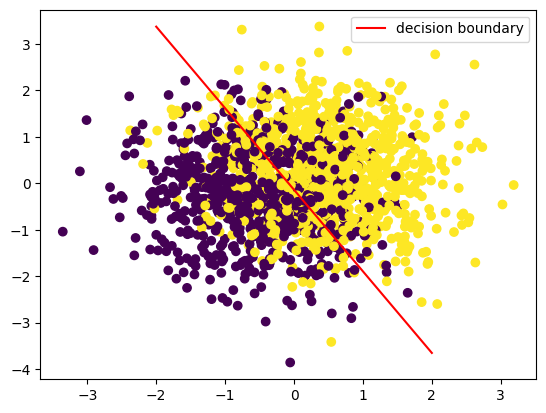

In [79]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

### Iterations: n_iteration = 1500

50. Training loss: 0.4210863364107006, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061348, Val loss:0.4052693942293411
150. Training loss: 0.3833104146387553, Val loss:0.38946444714134726
200. Training loss: 0.36844391326627834, Val loss:0.3759451207657198
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.34443109894084123, Val loss:0.35415496178424605
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.33744318725215144
450. Training loss: 0.31825604822090914, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966
550. Training loss: 0.30512120261559816, Val loss:0.31861866833458574
600. Training loss: 0.29947398138187187, Val loss:0.31352230201213016
650. Training loss: 0.29432499674933427, Val loss:0.3088748500410424
700. Training loss: 0.28960656875428886, Val loss:0.3046141303741866
750. Training loss: 0.28526247

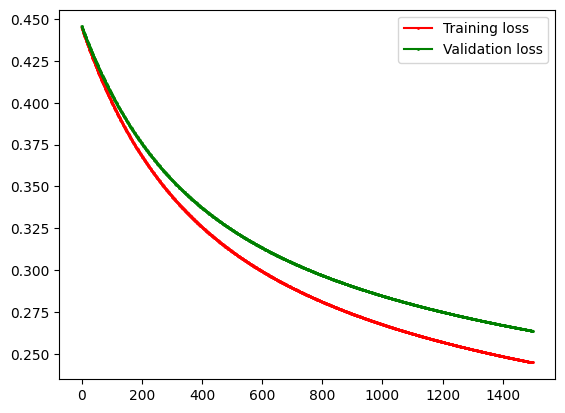

In [80]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration=1500,val_ratio=0.2)

In [81]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9256
Precision : 0.9393
Recall    : 0.9255
F1-score  : 0.9323


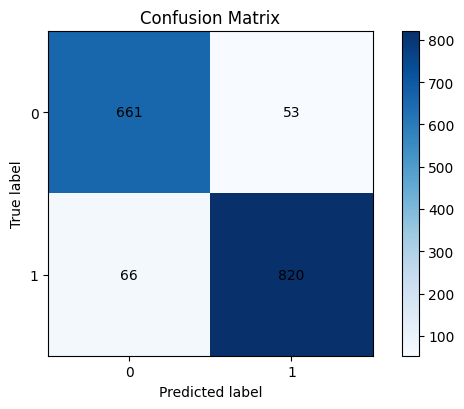

{'Accuracy': 0.925625,
 'Precision': 0.9392898052691867,
 'Recall': 0.9255079006772009,
 'F1-score': 0.9323479249573622}

In [82]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

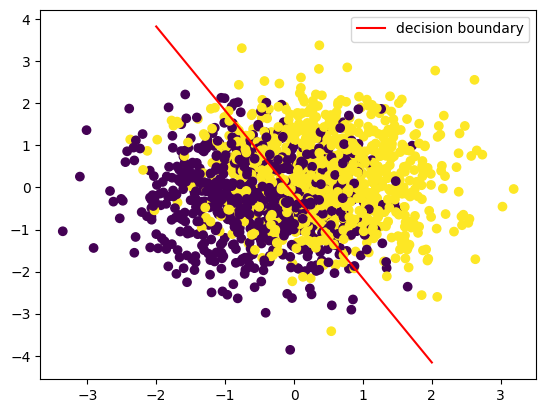

In [83]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

## Learning Rate: lr = 0.001

50. Training loss: 0.44221977024873593, Val loss:0.4436168074363421
100. Training loss: 0.4396594302179652, Val loss:0.4412701641807759
150. Training loss: 0.4371436725613987, Val loss:0.43896472084268623
200. Training loss: 0.4346715536135045, Val loss:0.4366996003801621
250. Training loss: 0.4322421495919633, Val loss:0.43447394458012223
300. Training loss: 0.4298545563023576, Val loss:0.43228691374881156
350. Training loss: 0.42750788883734553, Val loss:0.43013768639915717
400. Training loss: 0.42520128127118983, Val loss:0.4280254589357611
450. Training loss: 0.422933886350463, Val loss:0.4259494453382512
500. Training loss: 0.42070487518169253, Val loss:0.42390887684365186


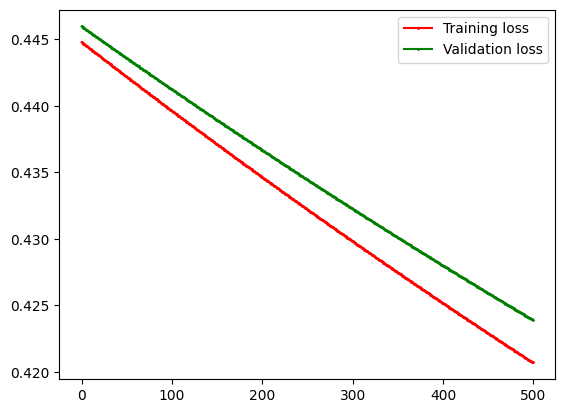

In [84]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.001,n_iteration=500,val_ratio=0.2)

In [85]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.8319
Precision : 0.8668
Recall    : 0.8228
F1-score  : 0.8442


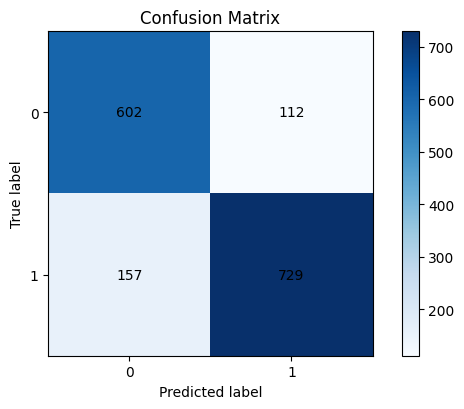

{'Accuracy': 0.831875,
 'Precision': 0.8668252080856124,
 'Recall': 0.8227990970654627,
 'F1-score': 0.8442385639837869}

In [86]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

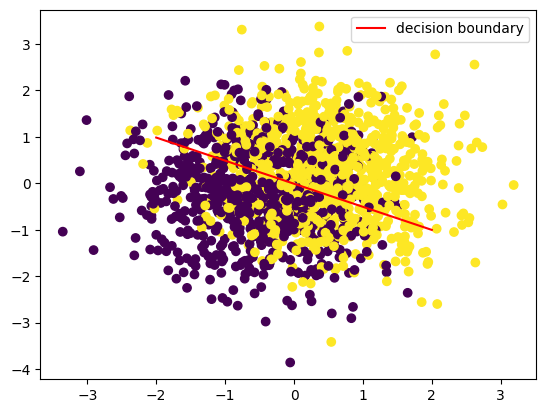

In [87]:
# Plot validation set and decision boundary
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()